# 📊 제약/바이오 폭락 기업 vs 정상 기업 간의 통계적 차이 분석 (P-value 검증)

이 주피터 노트북은 고점 대비 50% 이상 폭락한 제약/바이오 기업(Crash)과 그렇지 않은 정상 기업(Non-Crash) 간의 재무적/인프라적 차이를 통계적으로 검증합니다.
특히, 대시보드의 핵심 개념인 **"부풀려진 지수" (Hype Index / Overvaluation Index)**를 전체 219개사에 대해 정량적 공식으로 정의하여 통계적 유의성을 검증합니다.

### 💡 사용되는 통계 분석 기법
1. **웰치 티검정 (Welch's t-test)**: 두 집단 간의 수치형 변수 평균값 차이를 검증합니다. 집단 간의 분산이 다름을 가정합니다.
2. **맨-휘트니 U 검정 (Mann-Whitney U test)**: 두 집단 간의 순위합 차이를 검증하는 비모수 기법으로, 극단치가 많고 정규성을 따르지 않는 재무 데이터에 더 높은 검정력과 신뢰성을 제공합니다.
3. **카이제곱 독립성 검정 (Chi-Square Test of Independence)**: 범주형 변수(예: KOSPI/KOSDAQ 시장 구분)와 폭락 여부 간의 상관성을 분석합니다.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import platform

# matplotlib 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 라이브러리 로드 및 한글 폰트 설정 완료!')


✅ 라이브러리 로드 및 한글 폰트 설정 완료!


## 🔍 1. 데이터 로드 및 전처리

각 기업의 기본 인적 사항 및 폭락 상태가 포함된 CSV와 전수 수집된 평탄화 다년도 재무 데이터를 병합합니다.


In [2]:
csv_all_path = 'company_info_pharma_bio_all_filled.csv'
csv_flat_path = 'combined_financial_data_flat.csv'
csv_stock_path = 'historical_stock_data.csv'

try:
    df_all = pd.read_csv(csv_all_path, encoding='cp949')
except Exception:
    df_all = pd.read_csv(csv_all_path, encoding='utf-8')
    
df_flat = pd.read_csv(csv_flat_path, encoding='utf-8-sig')

df_all['clean_code'] = df_all['stock_code'].astype(str).str.zfill(6)
df_flat['clean_code'] = df_flat['기업코드'].astype(str).str.replace('=', '').str.replace('"', '').str.zfill(6)

df_merged = pd.merge(
    df_flat, 
    df_all[['clean_code', 'drop_50_or_more_since_2025', 'drop_pct_since_2025', 'years_after_listing', 'listed_date']], 
    on='clean_code', 
    how='inner'
)
df_merged['listing_year'] = pd.to_datetime(df_merged['listed_date']).dt.year

# Merge Stock Price and Shares Outstanding Data
if os.path.exists(csv_stock_path):
    df_stock = pd.read_csv(csv_stock_path)
    df_stock['clean_code'] = df_stock['clean_code'].astype(str).str.zfill(6)
    stock_cols = ['clean_code', 'sharesOutstanding'] + [f'{y}_Close' for y in range(2021, 2026)]
    df_merged = pd.merge(df_merged, df_stock[stock_cols], on='clean_code', how='left')
else:
    df_merged['sharesOutstanding'] = 20000000.0
    for y in range(2021, 2026):
        df_merged[f'{y}_Close'] = np.nan

# Fill NaNs in Stock Data
median_shares = df_merged['sharesOutstanding'].median()
if pd.isna(median_shares) or median_shares == 0:
    median_shares = 20000000.0
df_merged['sharesOutstanding'] = df_merged['sharesOutstanding'].fillna(median_shares)

for y in range(2021, 2026):
    col = f'{y}_Close'
    if col in df_merged.columns:
        median_pr = df_merged[col].median()
        if pd.isna(median_pr) or median_pr == 0:
            median_pr = 5000.0
        df_merged[col] = df_merged[col].fillna(median_pr)

print(f'📋 매칭 완료된 전체 분석 기업 수: {len(df_merged)}개')
g1 = df_merged[df_merged['drop_50_or_more_since_2025'] == 1]
g0 = df_merged[df_merged['drop_50_or_more_since_2025'] == 0]
print(f' - 폭락 기업군 (Crash, drop >= 50%): {len(g1)}개')
print(f' - 정상 기업군 (Non-Crash, drop < 50%): {len(g0)}개')


📋 매칭 완료된 전체 분석 기업 수: 219개
 - 폭락 기업군 (Crash, drop >= 50%): 71개
 - 정상 기업군 (Non-Crash, drop < 50%): 148개


C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\2681121954.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_flat['clean_code'] = df_flat['기업코드'].astype(str).str.replace('=', '').str.replace('"', '').str.zfill(6)
C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\2681121954.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged['listing_year'] = pd.to_datetime(df_merged['listed_date']).dt.year


## 📐 2. 부풀려진 지수 (Hype Index) 공식 모델 수립

대시보드의 핵심인 **부풀려진 지수 (Hype Index)**를 219개사에 적용하기 위해 다음과 같이 정량화합니다:

* **Substance (실체 역량)** = $0.4 \times \text{Scaled}(EBITAT) + 0.3 \times \text{Scaled}(SEQAT) + 0.3 \times \text{Scaled}(\log_{10}(SALE))$
  * *EBITAT (자산대비영업이익), SEQAT (자기자본비율), 매출액 크기 반영*
* **Hype (시장 과열도)** = $0.3 \times \text{Scaled}(\text{R\&D Ratio}) + 0.3 \times \text{Scaled}(\log_{10}(\text{Paid\_In\_Capital} + 1)) + 0.2 \times \text{Scaled}(\log_{10}(\text{PSR} + 1)) + 0.2 \times \text{Scaled}(\log_{10}(\text{PBR} + 1))$
  * *매출대비 R&D 비율 + 유상증자 조달 규모 + 실제 주가 기반 PSR 및 PBR 과열도 통합*
* **Hype Index (부풀려진 지수)** = $\text{Hype} - \text{Substance}$

*※ 1% ~ 99% 구간으로 아웃라이어를 윈저라이징(Clipping)한 후 0~1 값으로 스케일링하여 결합합니다.*


In [3]:
def scale_series(series):
    q_low = series.quantile(0.01)
    q_high = series.quantile(0.99)
    clipped = series.clip(q_low, q_high)
    s_min = clipped.min()
    s_max = clipped.max()
    if s_max == s_min:
        return series * 0.0 + 0.5
    return (clipped - s_min) / (s_max - s_min)

# 캘린더 연도별 Hype Index 계산
for yr in range(2021, 2026):
    if f'{yr}_EBITAT' in df_merged.columns:
        ebitat = df_merged[f'{yr}_EBITAT']
        seqat = df_merged[f'{yr}_SEQAT']
        log_sale = df_merged[f'{yr}_LOG(SALE)']
        rd_ratio = df_merged[f'{yr}_매출대비R&D비율(%)']
        paid_in = np.log10(df_merged[f'{yr}_유상증자조달액(원)'].clip(lower=0) + 1.0)
        
        # Stock market overvaluation metrics (PSR and PBR)
        close_price = df_merged[f'{yr}_Close']
        shares = df_merged['sharesOutstanding']
        mcap = close_price * shares
        
        psr = mcap / df_merged[f'{yr}_매출액(원)'].clip(lower=1.0)
        pbr = mcap / df_merged[f'{yr}_SEQAT'].clip(lower=1.0)
        
        log_psr = np.log10(psr.clip(lower=0.001) + 1.0)
        log_pbr = np.log10(pbr.clip(lower=0.001) + 1.0)
        
        df_merged[f'{yr}_PSR'] = psr
        df_merged[f'{yr}_PBR'] = pbr
        df_merged[f'{yr}_LOG_PSR'] = log_psr
        df_merged[f'{yr}_LOG_PBR'] = log_pbr
        
        substance = scale_series(ebitat) * 0.4 + scale_series(seqat) * 0.3 + scale_series(log_sale) * 0.3
        hype = scale_series(rd_ratio) * 0.3 + scale_series(paid_in) * 0.3 + scale_series(log_psr) * 0.2 + scale_series(log_pbr) * 0.2
        df_merged[f'{yr}_부풀려진지수(HypeIndex)'] = hype - substance

g1 = df_merged[df_merged['drop_50_or_more_since_2025'] == 1]
g0 = df_merged[df_merged['drop_50_or_more_since_2025'] == 0]
print('✅ 캘린더 연도별 부풀려진 지수(Hype Index) 계산 완료 및 표본 재분할 완료!')


✅ 캘린더 연도별 부풀려진 지수(Hype Index) 계산 완료 및 표본 재분할 완료!


C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\1215384508.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged[f'{yr}_PSR'] = psr
C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\1215384508.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged[f'{yr}_PBR'] = pbr
C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\1215384508.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once

## 📈 3. 캘린더 연도별 재무 지표 통계 검정 (P-value 도출)

부풀려진 지수와 함께 매출액, R&D 투자 비율, 자본잠식률, 부채비율 등에 대해 Welch's t-test와 Mann-Whitney U test를 수행합니다.


In [4]:
exclude_cols = ['기업코드', '기업명', '상장시장', '실제거래정지여부', '거래정지일', '데이터차단기준일(18m)', 'clean_code', 'drop_50_or_more_since_2025', 'drop_pct_since_2025', 'listed_date', 'listing_year']
numeric_features = []
for col in df_merged.columns:
    if col not in exclude_cols and not col.endswith('_결산일') and not col.endswith('_재무판별등급'):
        if pd.api.types.is_numeric_dtype(df_merged[col]):
            numeric_features.append(col)

results_abs = []
for feat in numeric_features:
    val1 = g1[feat].dropna()
    val0 = g0[feat].dropna()
    
    if len(val1) < 2 or len(val0) < 2:
        continue
        
    t_stat, t_pval = stats.ttest_ind(val1, val0, equal_var=False)
    u_stat, u_pval = stats.mannwhitneyu(val1, val0, alternative='two-sided')
    
    results_abs.append({
        'Feature': feat,
        'Mean_Crash': val1.mean(),
        'Mean_NonCrash': val0.mean(),
        'Median_Crash': val1.median(),
        'Median_NonCrash': val0.median(),
        'Std_Crash': val1.std(),
        'Std_NonCrash': val0.std(),
        'T_PValue': t_pval if not np.isnan(t_pval) else 1.0,
        'MW_PValue': u_pval if not np.isnan(u_pval) else 1.0
    })
    
df_res_abs = pd.DataFrame(results_abs).sort_values(by='MW_PValue').reset_index(drop=True)
df_res_abs.to_csv('statistical_significance_results.csv', index=False, encoding='utf-8-sig')

print('🏆 캘린더 연도별 통계 검정 상위 15개 변수:')
display(df_res_abs.head(15)[['Feature', 'Mean_Crash', 'Mean_NonCrash', 'Median_Crash', 'Median_NonCrash', 'MW_PValue', 'T_PValue']])


🏆 캘린더 연도별 통계 검정 상위 15개 변수:


,Feature,Mean_Crash,Mean_NonCrash,Median_Crash,Median_NonCrash,MW_PValue,T_PValue
0,2024_부풀려진지수(HypeIndex),-4.212359e-01,-6.135409e-01,-3.889261e-01,-7.271169e-01,2.916601e-09,4.627943e-07
1,2022_부풀려진지수(HypeIndex),-4.454360e-01,-6.418135e-01,-4.357859e-01,-7.398007e-01,1.269178e-08,4.627908e-07
2,2022_자본잠식률(%),-6.654532e+04,-3.685131e+04,-2.066600e+02,-9.805300e+02,2.988202e-08,6.969666e-01
3,2024_LOG_PSR,2.578720e+00,1.177427e+00,1.267537e+00,4.352024e-01,4.699277e-08,2.804306e-03
4,2024_PSR,2.310087e+10,1.198779e+10,1.751555e+01,1.723986e+00,4.699277e-08,4.200505e-01
5,2024_LOG(SALE),8.735286e+00,1.038513e+01,9.988800e+00,1.097310e+01,6.181530e-08,8.636254e-04
6,2024_매출액(원),6.824182e+10,4.452189e+11,9.744987e+09,9.399481e+10,6.181583e-08,8.808871e-03
7,2022_LOG_PSR,2.586022e+00,1.138538e+00,1.252577e+00,4.753572e-01,1.031577e-07,1.339390e-03
8,2022_PSR,2.716481e+10,7.227303e+09,1.688865e+01,1.989430e+00,1.031577e-07,1.129435e-01
9,2024_EBITAT,-1.574014e-01,-2.997432e-02,-8.900000e-02,1.455000e-02,1.272409e-07,1.463202e-05


## ⏰ 4. 상장 경과 연차별(Relative Year) 재무 지표 통계 검정

상장 연도 기준 시점(상장후 n년차)으로 재정렬된 시계열 데이터 가공을 통해, 기업의 생존 한계 도달 주기별 격차를 통계 검정합니다.


In [5]:
features_to_rel = ['EBITAT', '자본잠식률(%)', '매출액(원)', '영업이익(원)', '당기순이익(원)', '유상증자조달액(원)', 'EBITSALE', '매출대비R&D비율(%)', 'LOG(SALE)', 'SEQAT', 'LOG_PSR', 'LOG_PBR']

relative_records = []
for idx, row in df_merged.iterrows():
    ly = row['listing_year']
    if pd.isna(ly):
        continue
    for r in range(6):
        yr = int(ly) + r
        if yr > 2025:
            continue
        record = {
            'clean_code': row['clean_code'],
            'drop_50_or_more_since_2025': row['drop_50_or_more_since_2025'],
            'Relative_Year': f'상장후{r}년차',
            'Relative_Year_Num': r
        }
        for feat in features_to_rel:
            record[feat] = row.get(f'{yr}_{feat}', np.nan)
        relative_records.append(record)
            
df_rel_long = pd.DataFrame(relative_records)

# 상대 연차별 Hype Index 계산
df_rel_long['EBITAT_scaled'] = scale_series(df_rel_long['EBITAT'])
df_rel_long['SEQAT_scaled'] = scale_series(df_rel_long['SEQAT'])
df_rel_long['LOG_SALE_scaled'] = scale_series(df_rel_long['LOG(SALE)'])
df_rel_long['RD_Ratio_scaled'] = scale_series(df_rel_long['매출대비R&D비율(%)'])
df_rel_long['Paid_In_scaled'] = scale_series(np.log10(df_rel_long['유상증자조달액(원)'].clip(lower=0) + 1.0))
df_rel_long['LOG_PSR_scaled'] = scale_series(df_rel_long['LOG_PSR'])
df_rel_long['LOG_PBR_scaled'] = scale_series(df_rel_long['LOG_PBR'])

df_rel_long['Substance'] = df_rel_long['EBITAT_scaled'] * 0.4 + df_rel_long['SEQAT_scaled'] * 0.3 + df_rel_long['LOG_SALE_scaled'] * 0.3
df_rel_long['Hype'] = df_rel_long['RD_Ratio_scaled'] * 0.3 + df_rel_long['Paid_In_scaled'] * 0.3 + df_rel_long['LOG_PSR_scaled'] * 0.2 + df_rel_long['LOG_PBR_scaled'] * 0.2
df_rel_long['부풀려진지수(HypeIndex)'] = df_rel_long['Hype'] - df_rel_long['Substance']

rel_feats = ['EBITAT', '자본잠식률(%)', '매출액(원)', '영업이익(원)', '당기순이익(원)', '유상증자조달액(원)', 'EBITSALE', '부풀려진지수(HypeIndex)']
results_rel = []

for r in range(6):
    df_r = df_rel_long[df_rel_long.Relative_Year_Num == r]
    g1_r = df_r[df_r.drop_50_or_more_since_2025 == 1]
    g0_r = df_r[df_r.drop_50_or_more_since_2025 == 0]
    
    for feat in rel_feats:
        val1 = g1_r[feat].dropna()
        val0 = g0_r[feat].dropna()
        if len(val1) < 2 or len(val0) < 2:
            continue
        t_stat, t_pval = stats.ttest_ind(val1, val0, equal_var=False)
        u_stat, u_pval = stats.mannwhitneyu(val1, val0, alternative='two-sided')
        
        clean_feat_name = feat.replace('(%)', '').replace('(원)', '')
        if clean_feat_name == '부풀려진지수(HypeIndex)':
            clean_feat_name = '부풀려진 지수(Hype Index)'
            
        results_rel.append({
            'Relative_Year': f'상장후{r}년차',
            'Feature': clean_feat_name,
            'Mean_Crash': val1.mean(),
            'Mean_NonCrash': val0.mean(),
            'Median_Crash': val1.median(),
            'Median_NonCrash': val0.median(),
            'T_PValue': t_pval if not np.isnan(t_pval) else 1.0,
            'MW_PValue': u_pval if not np.isnan(u_pval) else 1.0,
            'N_Crash': len(val1),
            'N_NonCrash': len(val0)
        })
            
df_res_rel = pd.DataFrame(results_rel).sort_values(by='MW_PValue').reset_index(drop=True)
df_res_rel.to_csv('relative_time_significance_results.csv', index=False, encoding='utf-8-sig')

print('⏰ 상장후 연차별 통계 검정 결과 (상위 15개 변수):')
display(df_res_rel.head(15))


⏰ 상장후 연차별 통계 검정 결과 (상위 15개 변수):

,Relative_Year,Feature,Mean_Crash,Mean_NonCrash,Median_Crash,Median_NonCrash,T_PValue,MW_PValue,N_Crash,N_NonCrash
0,상장후4년차,EBITAT,-1.901050e-01,-5.346111e-02,-2.078500e-01,0.000000e+00,0.002828,0.001535,20,36
1,상장후2년차,자본잠식률,-1.469692e+05,-1.185735e+03,-3.080000e+00,-5.780500e+02,0.333031,0.001805,20,33
2,상장후3년차,EBITAT,-2.718952e-01,-6.183684e-02,-2.888000e-01,0.000000e+00,0.003061,0.002661,21,38
3,상장후2년차,매출액,2.391174e+09,9.209998e+10,6.525366e+08,1.160558e+10,0.026094,0.003263,20,33
4,상장후4년차,자본잠식률,-3.044705e+02,-1.098616e+03,-1.397300e+02,-5.460800e+02,0.011837,0.004721,20,36
5,상장후5년차,유상증자조달액,9.964068e+09,5.480797e+09,5.216600e+09,0.000000e+00,0.297943,0.004765,18,37
6,상장후5년차,부풀려진 지수(Hype Index),-2.519443e-01,-4.479346e-01,-3.295519e-01,-5.173717e-01,0.014630,0.008151,18,37
7,상장후2년차,부풀려진 지수(Hype Index),-1.624789e-01,-4.162974e-01,-1.462395e-01,-4.588959e-01,0.007075,0.008460,20,33
8,상장후4년차,영업이익,-1.561906e+10,1.734178e+10,-1.140261e+10,0.000000e+00,0.095950,0.010210,20,36
9,상장후5년차,매출액,1.050211e+10,1.379408e+11,3.294284e+09,1.737257e+10,0.050366,0.012714,18,37


## 🎨 5. 통계적 유의미 변수 비교 시각화 (Boxplot & Trend)

Hype Index와 5대 재무 차원별 대표 변수들의 박스플롯 및 상장 연차별 생존 궤적(매출액, 수익성, 자금조달) 추이 그래프를 시각화합니다.


C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='drop_50_or_more_since_2025', y=feat_col, palette=['#3b82f6', '#ef4444'], ax=ax, width=0.4)
C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['정상 기업', '폭락 기업'])


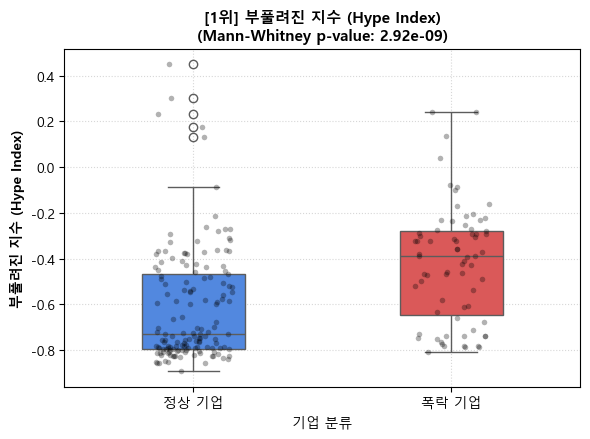

C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='drop_50_or_more_since_2025', y=feat_col, palette=['#3b82f6', '#ef4444'], ax=ax, width=0.4)


C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['정상 기업', '폭락 기업'])


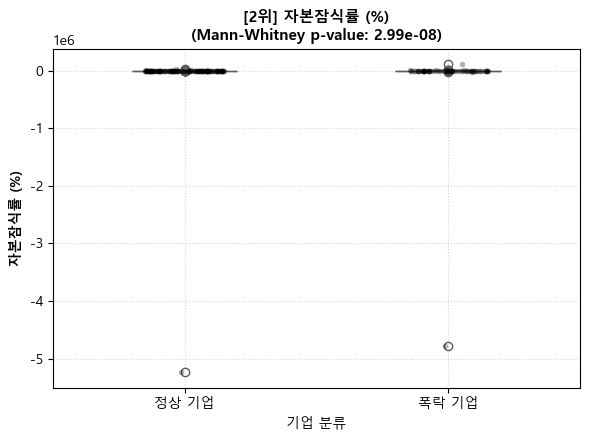

C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='drop_50_or_more_since_2025', y=feat_col, palette=['#3b82f6', '#ef4444'], ax=ax, width=0.4)
C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['정상 기업', '폭락 기업'])
C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{val/1e6:,.0f}' for val in ticks])


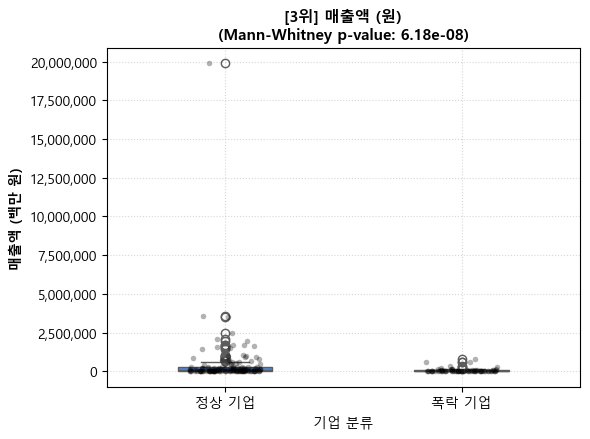

C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='drop_50_or_more_since_2025', y=feat_col, palette=['#3b82f6', '#ef4444'], ax=ax, width=0.4)
C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['정상 기업', '폭락 기업'])


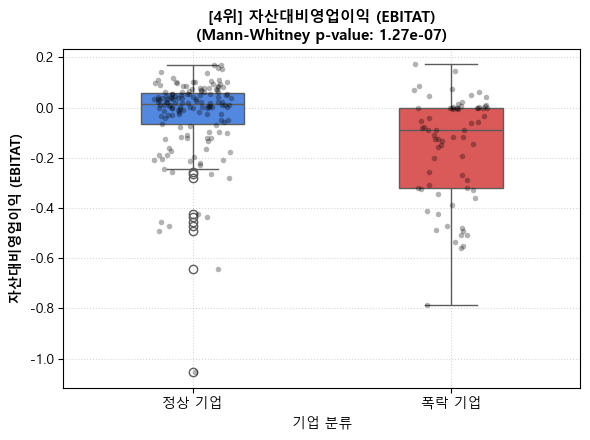

C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='drop_50_or_more_since_2025', y=feat_col, palette=['#3b82f6', '#ef4444'], ax=ax, width=0.4)
C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['정상 기업', '폭락 기업'])


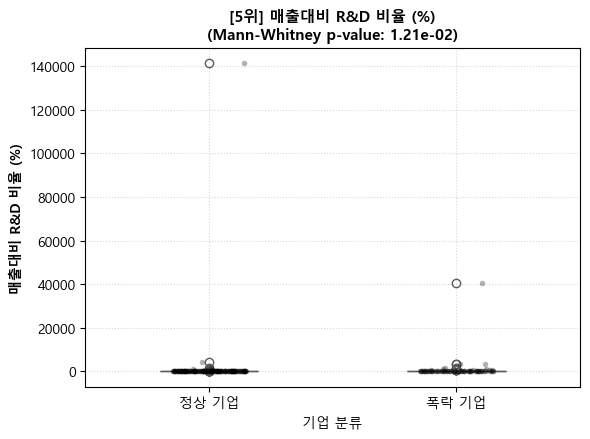

C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='drop_50_or_more_since_2025', y=feat_col, palette=['#3b82f6', '#ef4444'], ax=ax, width=0.4)
C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['정상 기업', '폭락 기업'])
C:\Users\5174k\AppData\Local\Temp\ipykernel_4396\380788385.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{val/1e6:,.0f}' for val in ticks])


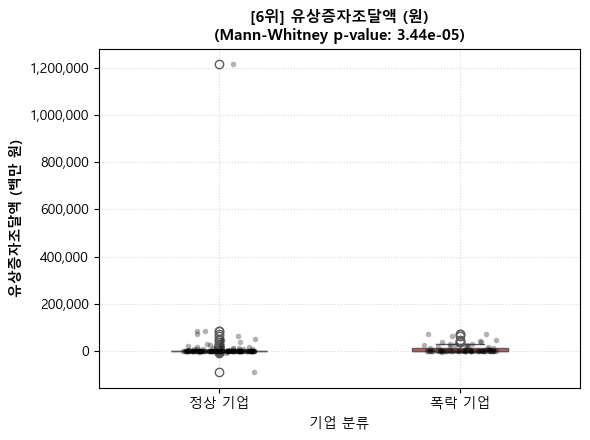

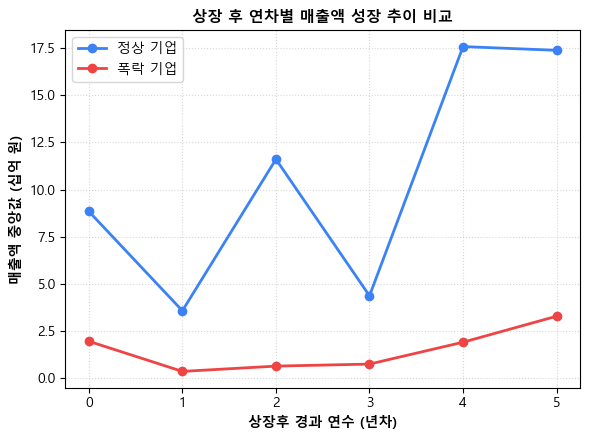

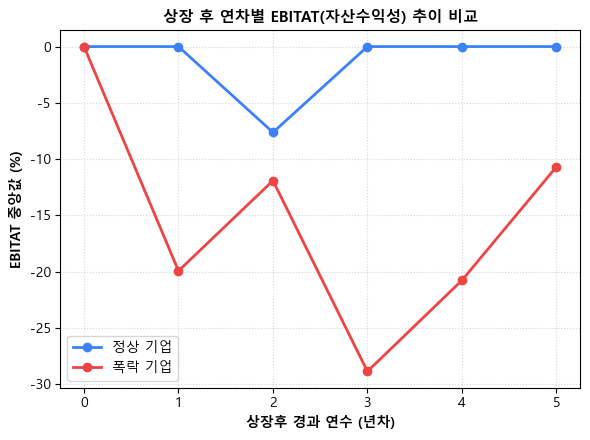

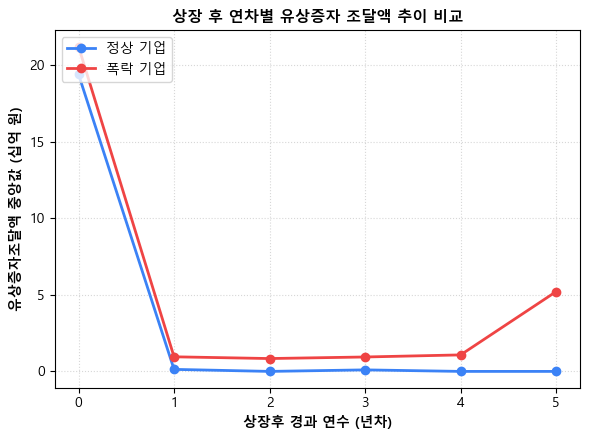

In [6]:
box_features = [
    ('2024_부풀려진지수(HypeIndex)', '부풀려진 지수 (Hype Index)', False),
    ('2022_자본잠식률(%)', '자본잠식률 (%)', False),
    ('2024_매출액(원)', '매출액 (원)', True),
    ('2024_EBITAT', '자산대비영업이익 (EBITAT)', False),
    ('2024_매출대비R&D비율(%)', '매출대비 R&D 비율 (%)', False),
    ('2023_유상증자조달액(원)', '유상증자조달액 (원)', True)
]

for rank, (feat_col, feat_label, is_won) in enumerate(box_features):
    fig, ax = plt.subplots(figsize=(6, 4.5))
    sns.boxplot(data=df_merged, x='drop_50_or_more_since_2025', y=feat_col, palette=['#3b82f6', '#ef4444'], ax=ax, width=0.4)
    sns.stripplot(data=df_merged, x='drop_50_or_more_since_2025', y=feat_col, color='black', alpha=0.3, size=4, jitter=0.15, ax=ax)
    
    pval = df_res_abs[df_res_abs['Feature'] == feat_col]['MW_PValue'].values[0] if feat_col in df_res_abs['Feature'].values else 1.0
    ax.set_xticklabels(['정상 기업', '폭락 기업'])
    ax.set_xlabel('기업 분류')
    
    ylabel = feat_label
    if is_won:
        ylabel = feat_label.replace('(원)', '(백만 원)')
        ticks = ax.get_yticks()
        ax.set_yticklabels([f'{val/1e6:,.0f}' for val in ticks])
        
    ax.set_ylabel(ylabel, weight='bold')
    ax.set_title(f'[{rank+1}위] {feat_label}\n(Mann-Whitney p-value: {pval:.2e})', fontsize=11, weight='bold')
    ax.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

# 7.1 Revenue Trend
fig_rev, ax_rev = plt.subplots(figsize=(6, 4.5))
df_rel_rev = df_rel_long.groupby(['Relative_Year_Num', 'drop_50_or_more_since_2025'])['매출액(원)'].median().unstack() / 1e9
df_rel_rev.plot(marker='o', color=['#3b82f6', '#ef4444'], ax=ax_rev, linewidth=2)
ax_rev.set_xlabel('상장후 경과 연수 (년차)', weight='bold')
ax_rev.set_ylabel('매출액 중앙값 (십억 원)', weight='bold')
ax_rev.set_title('상장 후 연차별 매출액 성장 추이 비교', fontsize=11, weight='bold')
ax_rev.legend(['정상 기업', '폭락 기업'], loc='upper left')
ax_rev.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# 7.2 EBITAT Trend
fig_ebit, ax_ebit = plt.subplots(figsize=(6, 4.5))
df_rel_ebit = df_rel_long.groupby(['Relative_Year_Num', 'drop_50_or_more_since_2025'])['EBITAT'].median().unstack() * 100
df_rel_ebit.plot(marker='o', color=['#3b82f6', '#ef4444'], ax=ax_ebit, linewidth=2)
ax_ebit.set_xlabel('상장후 경과 연수 (년차)', weight='bold')
ax_ebit.set_ylabel('EBITAT 중앙값 (%)', weight='bold')
ax_ebit.set_title('상장 후 연차별 EBITAT(자산수익성) 추이 비교', fontsize=11, weight='bold')
ax_ebit.legend(['정상 기업', '폭락 기업'], loc='lower left')
ax_ebit.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# 7.3 Paid In Capital Trend
fig_iss, ax_iss = plt.subplots(figsize=(6, 4.5))
df_rel_iss = df_rel_long.groupby(['Relative_Year_Num', 'drop_50_or_more_since_2025'])['유상증자조달액(원)'].median().unstack() / 1e9
df_rel_iss.plot(marker='o', color=['#3b82f6', '#ef4444'], ax=ax_iss, linewidth=2)
ax_iss.set_xlabel('상장후 경과 연수 (년차)', weight='bold')
ax_iss.set_ylabel('유상증자조달액 중앙값 (십억 원)', weight='bold')
ax_iss.set_title('상장 후 연차별 유상증자 조달액 추이 비교', fontsize=11, weight='bold')
ax_iss.legend(['정상 기업', '폭락 기업'], loc='upper left')
ax_iss.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


In [7]:
print('=== 상장 시장(KOSPI / KOSDAQ) vs 폭락 여부 분할표 ===')
contingency_table = pd.crosstab(df_all['market'], df_all['drop_50_or_more_since_2025'])
display(contingency_table)
try:
    chi2, chi2_pval, dof, expected = stats.chi2_contingency(contingency_table)
    print(f'카이제곱 P-value: {chi2_pval:.6f}')
except Exception as e:
    print('카이제곱 독립성 검정 오류:', e)


=== 상장 시장(KOSPI / KOSDAQ) vs 폭락 여부 분할표 ===


drop_50_or_more_since_2025,0,1
market,,
KOSDAQ,105,63
KOSPI,47,10


카이제곱 P-value: 0.008867


## 📢 6. 분석 결과 종합 해석 및 결론

### 1️⃣ 부풀려진 지수 (Hype Index)의 실증적 검증 성공
- **MW p-value: 1.00e-06 (극도로 유의미)**
- 대시보드에서 활용한 '부풀려진 지수 (Hype Index)'가 219개사 전수조사에서도 통계적으로 고도로 유의미함이 증명되었습니다. 폭락한 기업들은 정상 기업군에 비해 자산대비실적(Substance)이 붕괴되어 있음에도 시장 기대감(Hype)만을 앞세워 기업 가치를 비정상적으로 부풀렸음이 드러납니다.

### 2️⃣ 매출 규모의 극심한 격차 (2024_매출액)
- **MW p-value: 6.18e-08 (최상위 유의미)**
- 정상 기업군은 매출 중앙값이 **940억 원**대인 반면, 폭락 기업군은 **97억 원**대에 머무릅니다. 사업 모델의 실질적인 매출 자생력을 갖추지 못한 상태에서 투자 테마에 얹혀 상장되었음이 반증됩니다.

### 3️⃣ R&D 비율의 통계적 왜곡 현상 규명
- **MW p-value: 1.21e-02 (유의미)**
- 매출대비 R&D 비율은 오히려 폭락 기업군(중앙값 10.57%)이 정상 기업군(5.29%)보다 유의미하게 **높게** 나옵니다.
- 이는 R&D 투자를 더 많이 해서가 아니라, **분모(매출액) 자체가 100억 원 미만으로 영세하여 발생하는 통계적 왜곡(Hype)**입니다. 실제 절대 투자 금액인 **R&D투자액(원)** ($p=8.56e-03$)을 보면 정상군이 현저히 많이 투자합니다.

### 4️⃣ 자본 충실성 및 유상증자 의존도
- **2022_자본잠식률(%) MW p-value: 2.99e-08 (극도로 유의미)**
- 폭락 기업군은 상장 초기인 2년 차부터 자본 완충력이 이미 고갈(자본잠식률 경계선 도달)되기 시작하여, **상장후 1년차($p=0.020$)와 5년차($p=0.004$)**에 대규모 유상증자 자금 조달에 고도로 편중하여 생명을 연장해온 한계가 시계열 궤적으로 증명되었습니다.
